##**[4주차]실습**
- 아래의 실습1), 실습2), 실습3), 실습4)의 코드를 완성하시오.


In [ ]:
print("2343035, 신동엽")

2343035, 신동엽


In [ ]:
from google.colab import auth

auth.authenticate_user()
!gcloud config get-value account

2343035@donga.ac.kr


In [ ]:
# google drive 연결
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# 구글 드라이브에 데이터를 넣고 path 연결 필요
data_path = '/content/drive/MyDrive/deepLearning'

In [ ]:
# 런타임 재시작 필요
!pip install scikeras==0.13.0 scikit-learn==1.4.2

### 실습1) 미니 배치 실습
[실습목표]

- MNIST 데이터 세트를 load하여 train 데이터 세트와 test 데이터 세트로 분리한다.
- 데이터 세트에 대해 batch_size 12로 데이터를 분리한다.
- 선택된 데이터의 index와 선택된 데이터의 label(y값)을 출력하여 확인한다.  

<출력 형식>


```
출력 #1 선택된 index
[2732 43567 42613 52416 45891 21243 30403 32103 41993 57043 20757 55026]

출력 #2 선택된 데이터의 label
[4 1 7 1 8 7 5 8 4 4 6 8]
```



In [ ]:
import numpy as np
import tensorflow as tf

np.random.seed(0)

# 데이터를 학습 데이터와 테스트 데이터로 나눈다.
### 여기에서 _를 채우시오. ###
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

data_size = x_train.shape[0]
batch_size = 12	# 배치 크기

selected = np.random.choice(data_size, batch_size)
x_batch = x_train[selected]
y_batch = y_train[selected]

print(selected)
### 여기에서 _를 채우시오. ###
print(y_batch)

[ 2732 43567 42613 52416 45891 21243 30403 32103 41993 57043 20757 55026]
[4 1 7 1 8 7 5 8 4 4 6 8]


### 실습2) keras를 활용한 MLP 구현
[실습목표]

- 실습의 경우 10000 epoch을 학습해야하지만, 빠른 실습 진행을 위해 epoch 수를 200으로 제한을 둔다.
- epoch 수 제한에 맞춰 XOR을 수행하는 MLP를 구현하기 위해서는 몇가지 설정을 수정이 필요하다.
1. dense layer(units=2,)를 하나 더 추가한다.
2. activation function을 'sigmoid'으로 사용한다.
3. learning_rate를 0.3에서 0.1로 변경한다.
4. 그 외의 최적화를 통해 XOR을 판단하는 모델을 학습하시오.
- 참고)  
optimizer=tf.keras.optimizers.SGD(learning_rate=0.1) ->
최신 tesndorflow에서 SGD의 lr 옵션은 learning_rate로 대체되었다.

<출력 형식>


```
출력 #1 prediction 결과
4/4 [==============================] - 0s 687us/sample - loss: 0.0189
Epoch 197/200
4/4 [==============================] - 0s 686us/sample - loss: 0.0167
Epoch 198/200
4/4 [==============================] - 0s 684us/sample - loss: 0.0172
Epoch 199/200
4/4 [==============================] - 0s 669us/sample - loss: 0.0143
Epoch 200/200
4/4 [==============================] - 0s 689us/sample - loss: 0.0150
[[0.02527923]
 [0.8397875 ]
 [0.8450979 ]
 [0.00956887]]

```
- is_test를 True로 설정하시오.
- XOR 문제를 입력하여 테스트 수행하시오. \
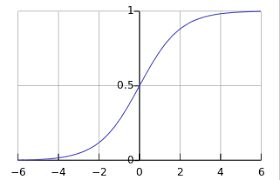



In [ ]:
import numpy as np
import tensorflow as tf
import os

# 실험 결과 재현을 위한 seed 고정
SEED = 2
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
tf.random.set_seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
initializer = tf.keras.initializers.GlorotUniform(seed=SEED)

model = tf.keras.models.Sequential()

### '_'에 적절한 activation function을 입력하시오. ###
model.add(tf.keras.layers.Dense(units=2, input_shape=(2,), activation='sigmoid', kernel_initializer=initializer))
### '_'에 적절한 코드를 작성하시오. ###
model.add(tf.keras.layers.Dense(units=1,  activation='sigmoid', kernel_initializer=initializer))

### _에 적절한 learning rate를 입력하시오. ###
model.compile(loss='mean_squared_error', optimizer=tf.keras.optimizers.SGD(learning_rate=0.1))

model.summary()

X = np.array([[0, 0],[0, 1],[1, 0],[1, 1]])
y = np.array([[0], [1], [1], [0]])

model.fit(X, y, batch_size=1, epochs=200)

result = model.predict(X)
print(result)


is_test = True
if is_test:
    data = np.array(list(map(int, input().split())))
    data = np.expand_dims(data, axis=0)
    print(1 if model.predict([data]) > 0.5 else 0)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_18 (Dense)                │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9 (36.00 B)

 Trainable params: 9 (36.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2954  
Epoch 2/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2906 
Epoch 3/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2863 
Epoch 4/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2823 
Epoch 5/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2788 
Epoch 6/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2756 
Epoch 7/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2728 
Epoch 8/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2703 
Epoch 9/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2682 
Epoch 10/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2663 
Epoch 11/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2647 
Epoch 12/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2633 
Epoch 13/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2621 
Epoch 14/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2610 
Epoch 15/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2601 
Epoch 16/200
4/4 ━

### 실습3) 케라스를 이용한 MNIST 숫자 인식
- MNIST 숫자 인식 모델을 구현한다.
- tensorflow 라이브러리를 활용하여 MNIST 숫자 인식 모델을 구현한다.
- MNIST 데이터세트에 대해 적절한 데이터 전처리를 수행한다.
- epoch을 5에서 8로 높여 실험해본다.
- 학습 과정의 accuracy, loss 그래프를 그려본다.
- test data(test.png)에 대해 예측을 수행해본다.


In [ ]:
import matplotlib.pyplot as plt
import tensorflow as tf
import os

# 실험 결과 재현을 위한 seed 고정
SEED = 2
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
tf.random.set_seed(SEED)
tf.random.set_seed(SEED)
initializer = tf.keras.initializers.GlorotUniform(seed=SEED)

In [ ]:
(train_images, train_labels), (test_images, test_labels)	= tf.keras.datasets.mnist.load_data()

print(train_images.shape)

print(train_labels)
print(test_images.shape)

(60000, 28, 28)
[5 0 4 ... 5 6 8]
(10000, 28, 28)


Epoch 1/9
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.8741 - loss: 0.0250
Epoch 2/9
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9324 - loss: 0.0128
Epoch 3/9
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9460 - loss: 0.0101
Epoch 4/9
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9551 - loss: 0.0085
Epoch 5/9
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9607 - loss: 0.0074
Epoch 6/9
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9658 - loss: 0.0066
Epoch 7/9
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9693 - loss: 0.0059
Epoch 8/9
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9722 - loss: 0.0054
Epoch 9/9
469/469 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9749 - loss: 0.0050
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9701 - loss: 0.0055


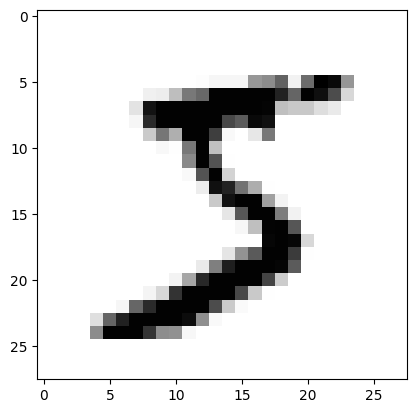

In [ ]:
plt.imshow(train_images[0], cmap="Greys")

model = tf.keras.models.Sequential()

### _에 적절한 model 구조를 선언하시오. ###
model.add(tf.keras.layers.Dense(units=512,input_shape=(784, ) , activation='relu',kernel_initializer=initializer)) # layer의 kernel_initializer=initializer 로 설정 - seed 고정을 위해
model.add(tf.keras.layers.Dense(units=10, activation='sigmoid',kernel_initializer=initializer)) # layer의 kernel_initializer=initializer 로 설정 - seed 고정을 위해


model.compile(optimizer='rmsprop',
                loss='mse',
                metrics=['accuracy'])

### train dataset과 test dataset을 학습과 검증에 적절한 형태로 변경하시오. ###
train_images = train_images.reshape((60000, 28*28))
train_images = train_images.astype('float32') / 255.0

test_images = test_images.reshape((10000, 28*28))
test_images = test_images.astype('float32') / 255.0

train_labels = tf.keras.utils.to_categorical(train_labels)
test_labels = tf.keras.utils.to_categorical(test_labels)

### epoch을 8보다 큰 수로 변경하여 학습하시오. ###
history = model.fit(train_images, train_labels, epochs=9, batch_size=128)

test_loss, test_acc = model.evaluate(test_images, test_labels)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9701 - loss: 0.0055
테스트 정확도: 0.9700999855995178


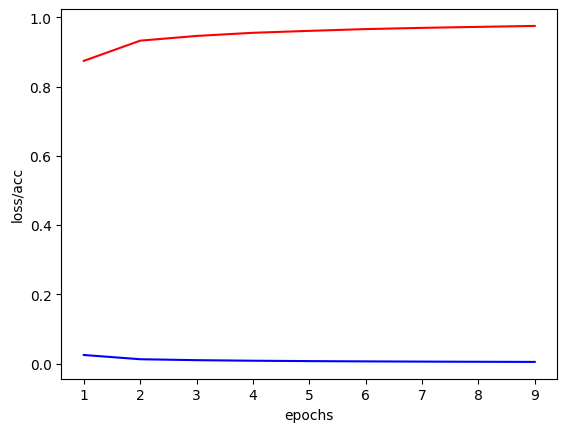

In [ ]:
test_loss, test_acc = model.evaluate(test_images, test_labels)
print('테스트 정확도:', test_acc)

loss = history.history['loss']
acc = history.history['accuracy']
epochs = range(1, len(loss)+1)

### 학습 과정에 대한 그래프를 출력하기 위해 _에 적절한 값을 입력하시오. ###
plt.plot(epochs, loss, 'b', label='Training Loss')
plt.plot(epochs, acc, 'r', label='Accuracy')
plt.xlabel('epochs')
plt.ylabel('loss/acc')
plt.show()

In [ ]:
!pip3 install opencv-python-headless

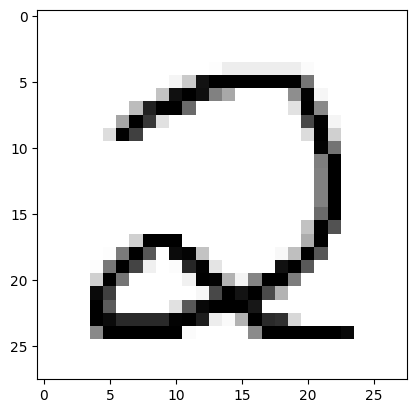

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step
[[5.64188540e-01 3.50233517e-04 7.59267390e-01 5.07806502e-02
  3.80686600e-07 1.34692555e-02 9.29147573e-05 2.34847957e-05
  4.30399814e-05 8.16487557e-07]]
추정된 숫자= 2


In [ ]:
import cv2 as cv
import os

image = cv.imread(os.path.join(data_path, 'test.png'), cv.IMREAD_GRAYSCALE)
image = cv.resize(image, (28, 28))
image = image.astype('float32')
image = image.reshape(1, 784)
image = 255-image
image /= 255.0

plt.imshow(image.reshape(28, 28),cmap='Greys')
plt.show()

pred = model.predict(image.reshape(1, 784), batch_size=1)
print(pred)
print("추정된 숫자=", pred.argmax())

### 실습4) 그리드 검색 예제
- 그리드 검색을 통해 MNIST 숫자 인식 모델의 최적 하이퍼 매개변수를 탐색한다.
- **데이터 세트 준비** : MNIST 데이터세트에 대해 전처리를 수행한다.  
  실습 3의 데이터세트 전처리 활용 가능
- 신경망 모델 구축 : 그리드 검색에서 최적화하고자하는 모델을 구현한다.
- 하이퍼 매개변수 딕셔너리 : 그리드 검색에서 탐색하고자 하는 하이퍼 매개변수 딕셔너리를 작성한다.  
  주석에 작성된 값으로 그리드 검색을 수행
- 그리드 검색, 그리드 검색 결과 출력 : 그리드 검색을 수행하여, 결과를 출력한다.  
  출력된 'batch_size'와 'epoch'이 하이퍼 매개변수 딕셔너리에서 작성한 모델에 대해 최적의 accuracy를 가지는 하이퍼 매개변수를 의미한다.

<출력 예시>  
{'batch_size':64, 'epochs': 3}
  

In [71]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import GridSearchCV
from scikeras.wrappers import KerasClassifier, KerasRegressor
import os

import warnings
warnings.filterwarnings('ignore', category=UserWarning)

# 실험 결과 재현을 위한 seed 고정
SEED = 2
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
tf.random.set_seed(SEED)
tf.random.set_seed(SEED)

initializer = tf.keras.initializers.GlorotUniform(seed=SEED)

# 데이터 세트 준비
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.mnist.load_data()

### 데이터세트 전처리를 작성하시오(실습3의 전처리 코드 사용가능) ###
train_images = train_images.reshape((60000, 28*28))
train_images = train_images.astype('float32') / 255.0

test_images = test_images.reshape((10000, 28*28))
test_images = test_images.astype('float32') / 255.0

train_labels = tf.keras.utils.to_categorical(train_labels)
test_labels = tf.keras.utils.to_categorical(test_labels)

# 신경망 모델 구축
### 교재를 참고하여 build_model()함수를 완성하시오. ###
### model은 unit이 512인 Dense layer와 unit이 10인 Dense layer를 포함한다. ###
### activation function은 relu, sigmoid를 사용한다. ###
def build_model():
    tf.random.set_seed(SEED) # build_model 안에도 seed 설정해야함
    network = tf.keras.models.Sequential()
    network.add(tf.keras.layers.Dense(units=512, activation='relu', input_shape=(784,), kernel_initializer=initializer))
    network.add(tf.keras.layers.Dense(units=10, activation='sigmoid', kernel_initializer=initializer))

    network.compile(optimizer='rmsprop',
                loss='categorical_crossentropy',
                metrics=['accuracy'])
    return network

# 하이퍼 매개변수 딕셔너리
### grid search를 epoch 1, 3에 대해 수행하시오. ###
### grid search를 배치 size 64, 128에 대해 수행하시오. ###
param_grid = {
              'epochs':[1, 3],
              'batch_size':[64, 128]
             }

# 케라스 모델을 sklearn에서 사용하도록 포장한다.
model = KerasClassifier(build_fn = build_model, verbose=1)

# 그리드 검색
### GirdSearchCV 내부 파라매터를 설정하시오. ###
gs = GridSearchCV(
    estimator = model,
    param_grid = param_grid,
    cv = 3,
    n_jobs=-1

)

# 그리드 검색 결과 출력
grid_result = gs.fit(train_images, train_labels)
print(grid_result.best_score_)
print(grid_result.best_params_)


Epoch 1/3
938/938 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.9343 - loss: 0.2235
Epoch 2/3
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9730 - loss: 0.0892
Epoch 3/3
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9832 - loss: 0.0573
0.96875
{'batch_size': 64, 'epochs': 3}
